## Notebook Overview

This notebook presents the complete pipeline for the language detection task, including data loading, preprocessing, exploratory analysis, feature extraction using TF-IDF, model training, evaluation, and inference on unseen examples.

| Section | Description |
|---|---|
| 1. Importing Libraries | Import required Python libraries and dependencies |
| 2. Data Loading | Load and combine the datasets |
| 3. Data Exploration | Analyze dataset structure and statistics |
| 4. Preprocessing | Clean and preprocess the text data |
| 5. Embedding & Training | Train and compare multiple TF-IDF models |
| 6. Test Data | Prepare and inspect test samples |
| 7. Inference on Test Examples | Perform predictions on unseen text examples |

# 1. Importing Libraries

In [27]:
from datasets import load_dataset
import plotly.express as px
import pycountry
import re
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import mlflow
import matplotlib.pyplot as plt
import pandas as pd
import random
import joblib
import os
from IPython.display import display


pd.set_option('display.max_colwidth', None)

---

# 2. Data Loading

In [2]:
ds = load_dataset("papluca/language-identification")
ds

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

---

# 3. Data Exploration

In [3]:
train_ds = ds['train'].to_pandas()
valid_ds = ds['validation'].to_pandas()
test_ds = ds['test'].to_pandas()
train_ds

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro."
1,bg,размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за на симулация .
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出就可以了，推荐给大家！！
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของเก่า ที่ ไม่ 29 สำหรับ เฟอร์นิเจอร์ และ เงิน ไท ร้อง บริษัท ที่ 122 สำหรับ ลาย คราม
4,ru,Он увеличил давление .
...,...,...
69995,ja,本格的なゲーミングヘッドホンでした。 今まで使ってた1万円するパナソニックのヘッドホンは何だったんだろうと思わすぐらい、音質もよくフィット感もあり、5時間ぐらいつけましたが全然疲れない仕様でした。もう大手メーカーの時代わ終わりましたね笑
69996,el,"Ναι , ξέρω ένα που είναι ακόμα έτσι , αλλά αυτό είναι ότι είμαι κάτω σε ένα φίλο που κρατάει αυτή τη θέση ακόμα είμαι η μόνη στο σπίτι αυτή τη στιγμή και έχω τα παιδιά να φωνάζουν για την προσοχή μου τώρα , οπότε καταλαβαίνω τι . Αυτό είναι σαν"
69997,ur,اور مجھے اس ملک کے بارے میں معلوم نہیں ہے کہ گزشتہ سال کے دوران ، میں گزشتہ سال کے بارے میں نہیں جانتا تھا ۔
69998,es,"Se me rompió uno al sacarlo del cargador. Calidad nefasta para el precio que tiene, no lo recomiendo. Que pesaos con las palabras que faltan para la opinión por Dios."


In [4]:
px.bar(train_ds['labels'].value_counts())

Data is balanced.

In [5]:
languages = train_ds['labels'].unique()
print(f"There are {len(languages)} unique language")
print(f"Languages: {languages}")

There are 20 unique language
Languages: ['pt' 'bg' 'zh' 'th' 'ru' 'pl' 'ur' 'sw' 'tr' 'es' 'ar' 'it' 'hi' 'de'
 'el' 'nl' 'fr' 'vi' 'en' 'ja']


In [6]:
def get_language_name(code):
    try:
        return pycountry.languages.get(alpha_2=code).name
    except AttributeError:
        return "Unknown"

# Map the codes from your dataset
full_names = {code: get_language_name(code) for code in languages}
pd.DataFrame([full_names]).T.set_axis(["full_name"], axis=1)

,full_name
pt,Portuguese
bg,Bulgarian
zh,Chinese
th,Thai
ru,Russian
pl,Polish
ur,Urdu
sw,Swahili (macrolanguage)
tr,Turkish
es,Spanish


In [7]:
train_ds.shape, valid_ds.shape, test_ds.shape

((70000, 2), (10000, 2), (10000, 2))

Let's investigate the length of the text in the data

In [8]:
train_ds["length"] = train_ds["text"].apply(len)
length_counts = train_ds["length"].value_counts().sort_index() # Count each length occurrence

train_ds["length"].describe()

count    70000.000000
mean       110.861414
std        103.106240
min          2.000000
25%         47.000000
50%         82.000000
75%        143.000000
max       2422.000000
Name: length, dtype: float64

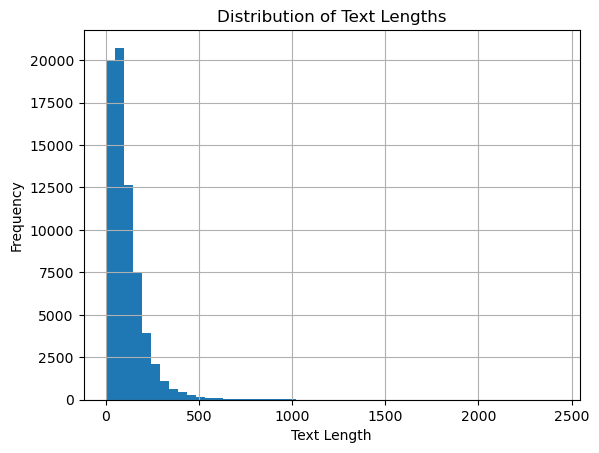

In [9]:
train_ds["length"].hist(bins=50)

plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")

plt.show()

This indicates an imbalanced text-length distribution. Most training examples are concise, while only a small portion contains very large text sequences.

In [10]:
p95 = int(train_ds["length"].quantile(0.95))
print(f"95th Percentile length: {p95} characters")

95th Percentile length: 281 characters


95% of the text samples are shorter than 281 characters, so a maximum length of 300 was selected to cover most samples while reducing padding and computation time.

---

# 4. Preprocessing


1. remove URLs and Emails
2. remove Numbers
3. trim text to 300 characters: We cap sequences at the 95th percentile to accelerate training and reduce memory usage while preserving the core signal.
4. normalize unicode: It makes visually or semantically equivalent characters become consistent internally.
5. lower casing
6. remove punctuation
7. remove extra spaces
8. remove spaces at the begginning and the end of the text

In [11]:
MAX_LEN = 300

def preprocess(text):
    # 1. Remove URLs and Emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)

    # 2. Remove Numbers (Language-agnostic noise)
    text = re.sub(r'\d+', '', text)

    # 3. Trim text to a maximum of 300 characters
    text = text[:MAX_LEN]

    # 4. Normalize unicode
    text = unicodedata.normalize("NFKC", text)

    # 5. Lower casing
    text = text.lower()

    # 6. Remove punctuation (Replaces symbols with spaces)
    text = re.sub(r'[^\w\s]', ' ', text)

    # 7. Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # 8. Strip leading/trailing spaces
    return text.strip()

In [12]:
train_ds['preprocessed_text'] = train_ds['text'].apply(preprocess)
valid_ds['text'] = valid_ds['text'].apply(preprocess)
test_ds['text'] = test_ds['text'].apply(preprocess)
train_ds

,labels,text,length,preprocessed_text
0,pt,"os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.",161,os chefes de defesa da estónia letónia lituânia alemanha itália espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro
1,bg,размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за на симулация .,131,размерът на хоризонталната мрежа може да бъде по реда на няколко километра km за на симулация до около km за на симулация
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出就可以了，推荐给大家！！,112,很好 以前从不去评价 不知道浪费了多少积分 现在知道积分可以换钱 就要好好评价了 后来我就把这段话复制走了 既能赚积分 还省事 走到哪复制到哪 最重要的是 不用认真的评论了 不用想还差多少字 直接发出就可以了 推荐给大家
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ของเก่า ที่ ไม่ 29 สำหรับ เฟอร์นิเจอร์ และ เงิน ไท ร้อง บริษัท ที่ 122 สำหรับ ลาย คราม,141,ส าหร บ ของเก า ท จร งจ ง ลอง honeychurch ของเก า ท ไม ส าหร บ เฟอร น เจอร และ เง น ไท ร อง บร ษ ท ท ส าหร บ ลาย คราม
4,ru,Он увеличил давление .,22,он увеличил давление
...,...,...,...,...
69995,ja,本格的なゲーミングヘッドホンでした。 今まで使ってた1万円するパナソニックのヘッドホンは何だったんだろうと思わすぐらい、音質もよくフィット感もあり、5時間ぐらいつけましたが全然疲れない仕様でした。もう大手メーカーの時代わ終わりましたね笑,118,本格的なゲーミングヘッドホンでした 今まで使ってた万円するパナソニックのヘッドホンは何だったんだろうと思わすぐらい 音質もよくフィット感もあり 時間ぐらいつけましたが全然疲れない仕様でした もう大手メーカーの時代わ終わりましたね笑
69996,el,"Ναι , ξέρω ένα που είναι ακόμα έτσι , αλλά αυτό είναι ότι είμαι κάτω σε ένα φίλο που κρατάει αυτή τη θέση ακόμα είμαι η μόνη στο σπίτι αυτή τη στιγμή και έχω τα παιδιά να φωνάζουν για την προσοχή μου τώρα , οπότε καταλαβαίνω τι . Αυτό είναι σαν",244,ναι ξέρω ένα που είναι ακόμα έτσι αλλά αυτό είναι ότι είμαι κάτω σε ένα φίλο που κρατάει αυτή τη θέση ακόμα είμαι η μόνη στο σπίτι αυτή τη στιγμή και έχω τα παιδιά να φωνάζουν για την προσοχή μου τώρα οπότε καταλαβαίνω τι αυτό είναι σαν
69997,ur,اور مجھے اس ملک کے بارے میں معلوم نہیں ہے کہ گزشتہ سال کے دوران ، میں گزشتہ سال کے بارے میں نہیں جانتا تھا ۔,108,اور مجھے اس ملک کے بارے میں معلوم نہیں ہے کہ گزشتہ سال کے دوران میں گزشتہ سال کے بارے میں نہیں جانتا تھا
69998,es,"Se me rompió uno al sacarlo del cargador. Calidad nefasta para el precio que tiene, no lo recomiendo. Que pesaos con las palabras que faltan para la opinión por Dios.",166,se me rompió uno al sacarlo del cargador calidad nefasta para el precio que tiene no lo recomiendo que pesaos con las palabras que faltan para la opinión por dios


Data augmentation will be applied to short texts to increase data variation and improve model generalization.

In [13]:
# Short-text augmentation per language
def make_short_variants(text, rng, max_len=30, min_len=2, max_variants=6):
    text = str(text).strip()
    if not text:
        return []
    candidates = []
    tokens = text.split()
    if tokens:
        for span in (1, 2, 3):
            if len(tokens) >= span:
                start = rng.randint(0, len(tokens) - span)
                candidates.append(" ".join(tokens[start:start + span]))
        candidates.append(tokens[0])
    if len(text) >= min_len:
        for target_len in (3, 5, 8, 10):
            if len(text) >= target_len:
                start = rng.randint(0, len(text) - target_len)
                candidates.append(text[start:start + target_len])
        candidates.append(text[:min(10, len(text))])
        candidates.append(text[-min(10, len(text)):])
    out = []
    seen = set()
    for c in candidates:
        c = c.strip()
        if min_len <= len(c) <= max_len and c not in seen:
            out.append(c)
            seen.add(c)
        if len(out) >= max_variants:
            break
    return out


def build_short_augments(df, per_lang=200, seed=42, max_len=30):
    rng = random.Random(seed)
    source_col = "preprocessed_text" if "preprocessed_text" in df.columns else "text"
    augmented_rows = []
    for label, group in df.groupby("labels"):
        n = min(per_lang, len(group))
        sample = group.sample(n=n, replace=len(group) < per_lang, random_state=seed)
        for text in sample[source_col].astype(str).tolist():
            for variant in make_short_variants(text, rng=rng, max_len=max_len):
                processed = variant if source_col == "preprocessed_text" else preprocess(variant)
                if not processed:
                    continue
                augmented_rows.append(
                    {
                        "text": variant,
                        "labels": label,
                        "preprocessed_text": processed,
                        "length": len(processed),
                    }
                )
    aug_df = pd.DataFrame(augmented_rows)
    aug_df = aug_df.drop_duplicates(subset=["preprocessed_text", "labels"])
    for col in df.columns:
        if col not in aug_df.columns:
            aug_df[col] = pd.NA
    aug_df = aug_df[df.columns]
    return aug_df


aug_df = build_short_augments(train_ds, per_lang=200, seed=42, max_len=30)
train_ds = pd.concat([train_ds, aug_df], ignore_index=True)
train_ds = train_ds.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Augmented rows: {len(aug_df):,}")
print(f"Train size after augmentation: {len(train_ds):,}")


Augmented rows: 20,441
Train size after augmentation: 90,441


---

# 5. Embedding & Training

In [14]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("language-detection")

def train_and_log_tfidf(name, ngram_range, analyzer="word", max_features=30000):
    run_name = name

    with mlflow.start_run(run_name=run_name) as run:
        # 1. Vectorization
        vectorizer = TfidfVectorizer(
            ngram_range=ngram_range,
            analyzer=analyzer,
            max_features=max_features,
        )
        X_train = vectorizer.fit_transform(train_ds["preprocessed_text"])
        X_valid = vectorizer.transform(valid_ds["text"])

        # 2. Training
        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, train_ds["labels"])

        # 3. Evaluation
        preds = model.predict(X_valid)
        acc = accuracy_score(valid_ds["labels"], preds)

        # 4. Logging
        mlflow.sklearn.log_model(model, "model")
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("max_features", max_features)
        mlflow.log_param("analyzer", analyzer)
        mlflow.log_metric("accuracy", acc)

        # Confusion Matrix
        fig, ax = plt.subplots(figsize=(12, 12))
        ConfusionMatrixDisplay.from_predictions(
            valid_ds["labels"],
            preds,
            display_labels=model.classes_,
            ax=ax,
            cmap="Blues",
            normalize="true",
        )
        plt.title(f"CM: {run_name}")
        plt.savefig("temp_cm.png")
        mlflow.log_artifact("temp_cm.png")
        plt.show()
        plt.close(fig)

        print(f"Finished {run_name} | Run ID: {run.info.run_id} | Accuracy: {acc:.4f}")
        return {
            "name": name,
            "run_id": run.info.run_id,
            "model": model,
            "vectorizer": vectorizer,
            "accuracy": acc,
            "ngram_range": ngram_range,
            "analyzer": analyzer,
            "max_features": max_features,
        }

experiment_results = []

2026/05/19 17:42:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/19 17:42:15 INFO mlflow.store.db.utils: Updating database tables
2026/05/19 17:42:17 INFO mlflow.tracking.fluent: Experiment with name 'language-detection' does not exist. Creating a new experiment.


##### TF-IDF 30k with ngram(1, 2) analyzer='word'

2026/05/19 17:42:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:42:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


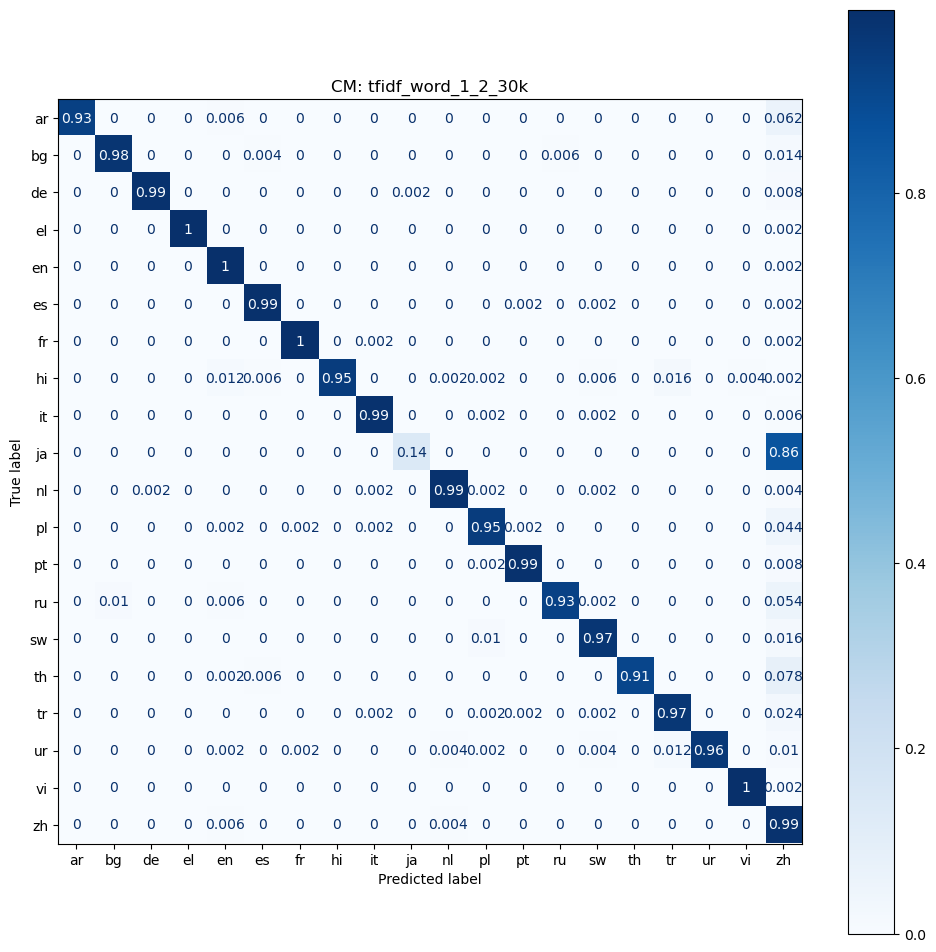

Finished tfidf_word_1_2_30k | Run ID: e574f7bf4862411795de413c0d049551 | Accuracy: 0.9313


In [15]:
result_tfidf_word_1_2_30k = train_and_log_tfidf(
    name="tfidf_word_1_2_30k",
    ngram_range=(1, 2),
    analyzer="word",
    max_features=30000,
)
experiment_results.append(result_tfidf_word_1_2_30k)

##### TF-IDF 30k with ngram(2, 5) analyzer='word'

2026/05/19 17:42:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:42:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


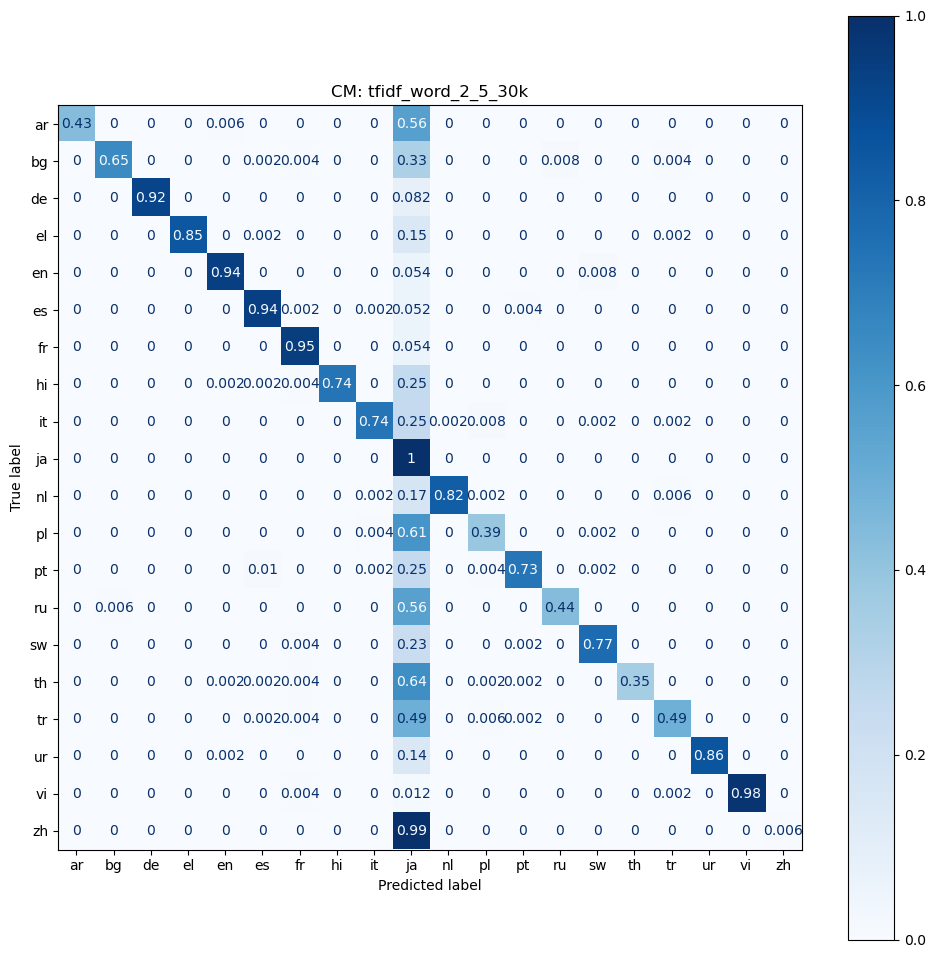

Finished tfidf_word_2_5_30k | Run ID: ddd2c0c4b09149f5bd13c93941f3e5de | Accuracy: 0.6991


In [16]:
result_tfidf_word_2_5_30k = train_and_log_tfidf(
    name="tfidf_word_2_5_30k",
    ngram_range=(2, 5),
    analyzer="word",
    max_features=30000,
)
experiment_results.append(result_tfidf_word_2_5_30k)

##### TF-IDF 30k with ngram(1, 5) analyzer='word'

2026/05/19 17:43:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:43:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


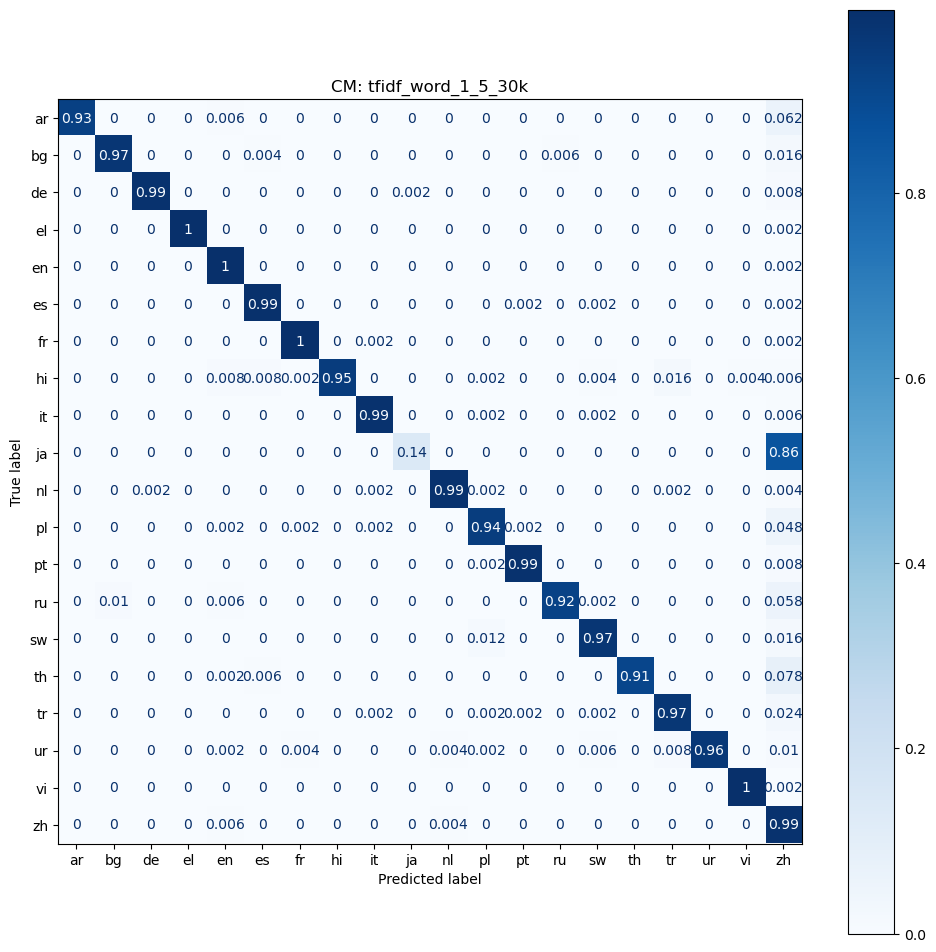

Finished tfidf_word_1_5_30k | Run ID: 20f3a5f460054ee2a63bbc94c8cf5391 | Accuracy: 0.9307


In [17]:
result_tfidf_word_1_5_30k = train_and_log_tfidf(
    name="tfidf_word_1_5_30k",
    ngram_range=(1, 5),
    analyzer="word",
    max_features=30000,
)
experiment_results.append(result_tfidf_word_1_5_30k)

##### TF-IDF 35k with ngram(1, 5) analyzer='word'

2026/05/19 17:43:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:43:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


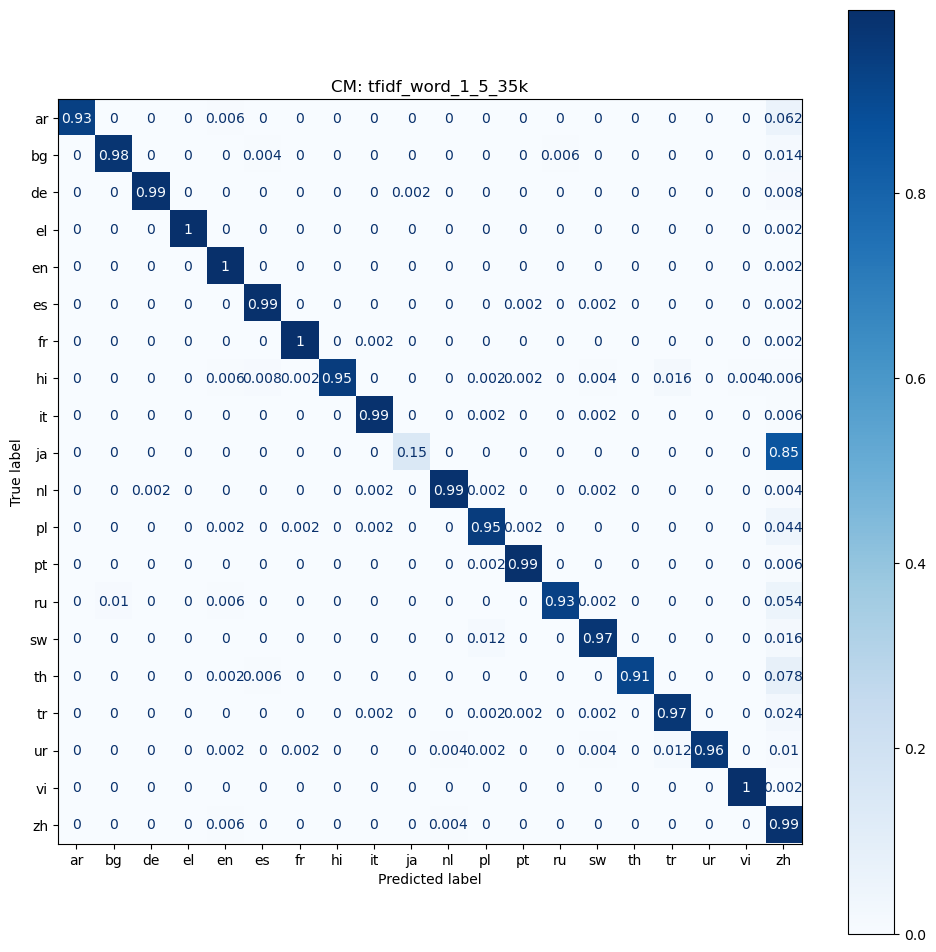

Finished tfidf_word_1_5_35k | Run ID: 755e4f2955e3472da8c46f1b3e61e889 | Accuracy: 0.9316


In [18]:
result_tfidf_word_1_5_35k = train_and_log_tfidf(
    name="tfidf_word_1_5_35k",
    ngram_range=(1, 5),
    analyzer="word",
    max_features=35000,
)
experiment_results.append(result_tfidf_word_1_5_35k)

##### TF-IDF 30k with ngram(1, 2) analyzer='char'

2026/05/19 17:44:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:44:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


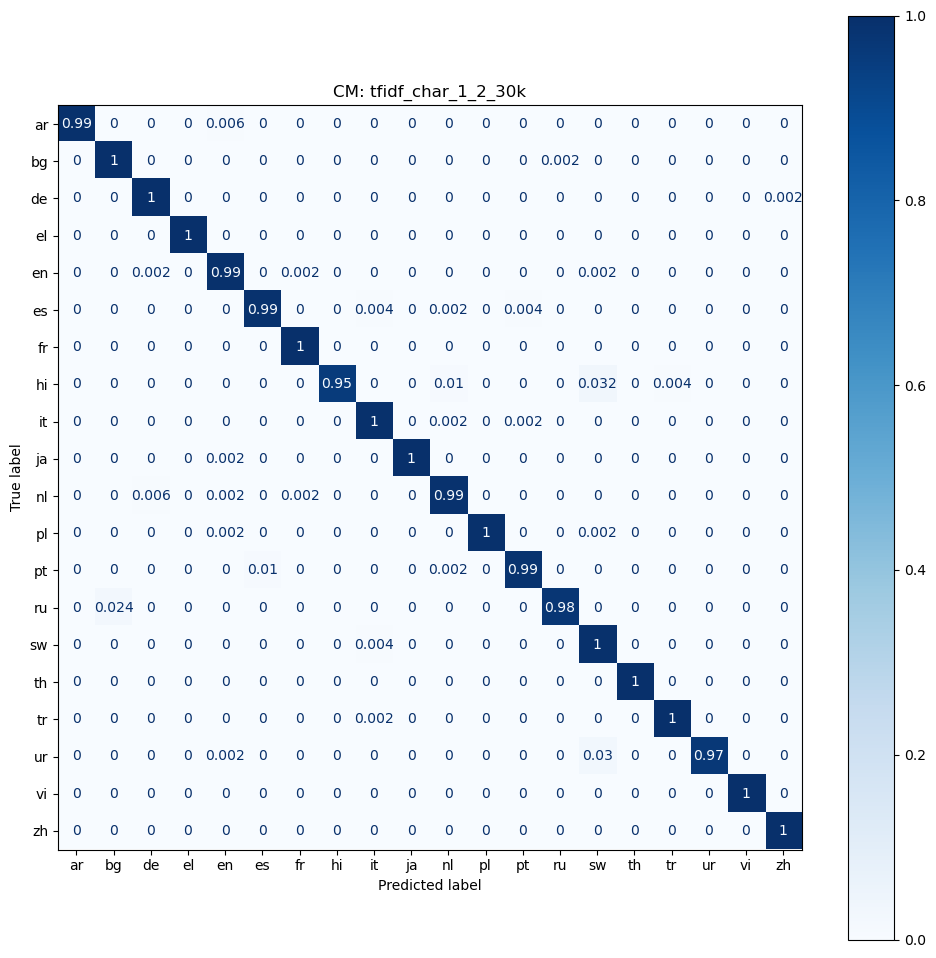

Finished tfidf_char_1_2_30k | Run ID: 6e9c058b114b4755996f0cf9a3379546 | Accuracy: 0.9917


In [19]:
result_tfidf_char_1_2_30k = train_and_log_tfidf(
    name="tfidf_char_1_2_30k",
    ngram_range=(1, 2),
    analyzer="char",
    max_features=30000,
)
experiment_results.append(result_tfidf_char_1_2_30k)

##### TF-IDF 30k with ngram(1, 3) analyzer='char'

2026/05/19 17:44:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:44:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


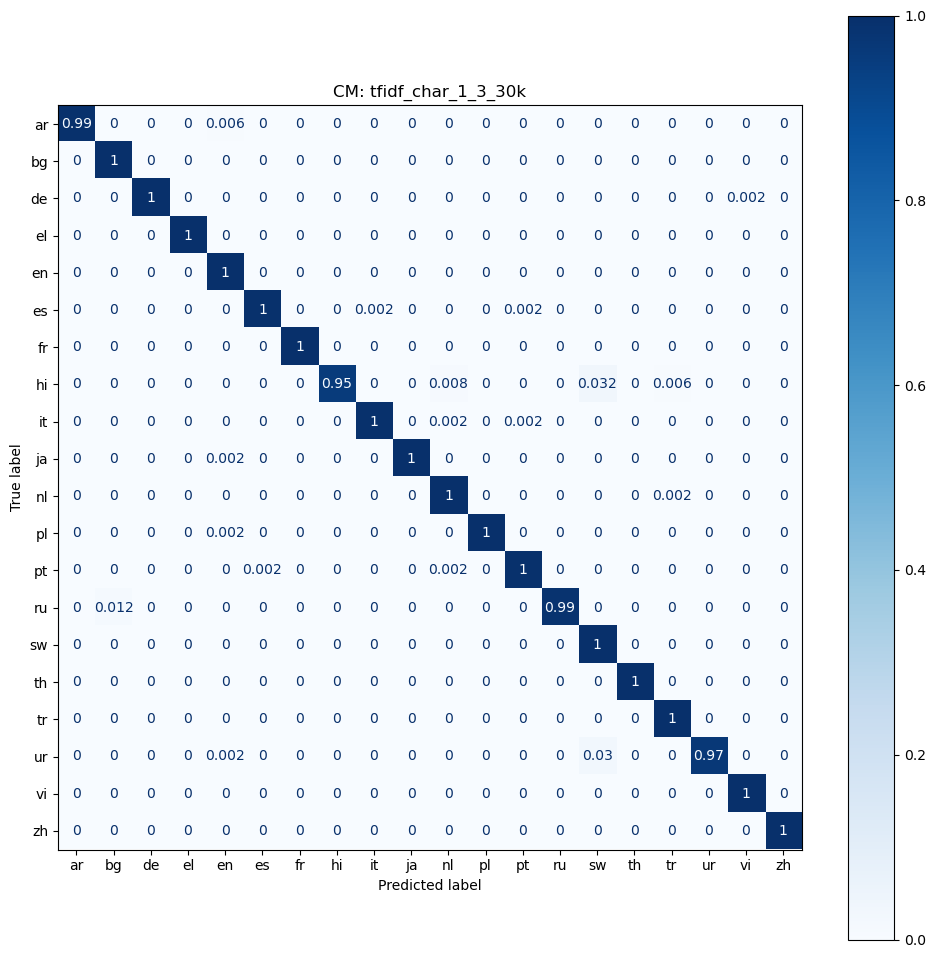

Finished tfidf_char_1_3_30k | Run ID: 166caaab93ed441aaf88774246447cad | Accuracy: 0.9942


In [20]:
result_tfidf_char_1_3_30k = train_and_log_tfidf(
    name="tfidf_char_1_3_30k",
    ngram_range=(1, 3),
    analyzer="char",
    max_features=30000,
)
experiment_results.append(result_tfidf_char_1_3_30k)

##### TF-IDF 30k with ngram(1, 3) analyzer='char_wb'

2026/05/19 17:45:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:45:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


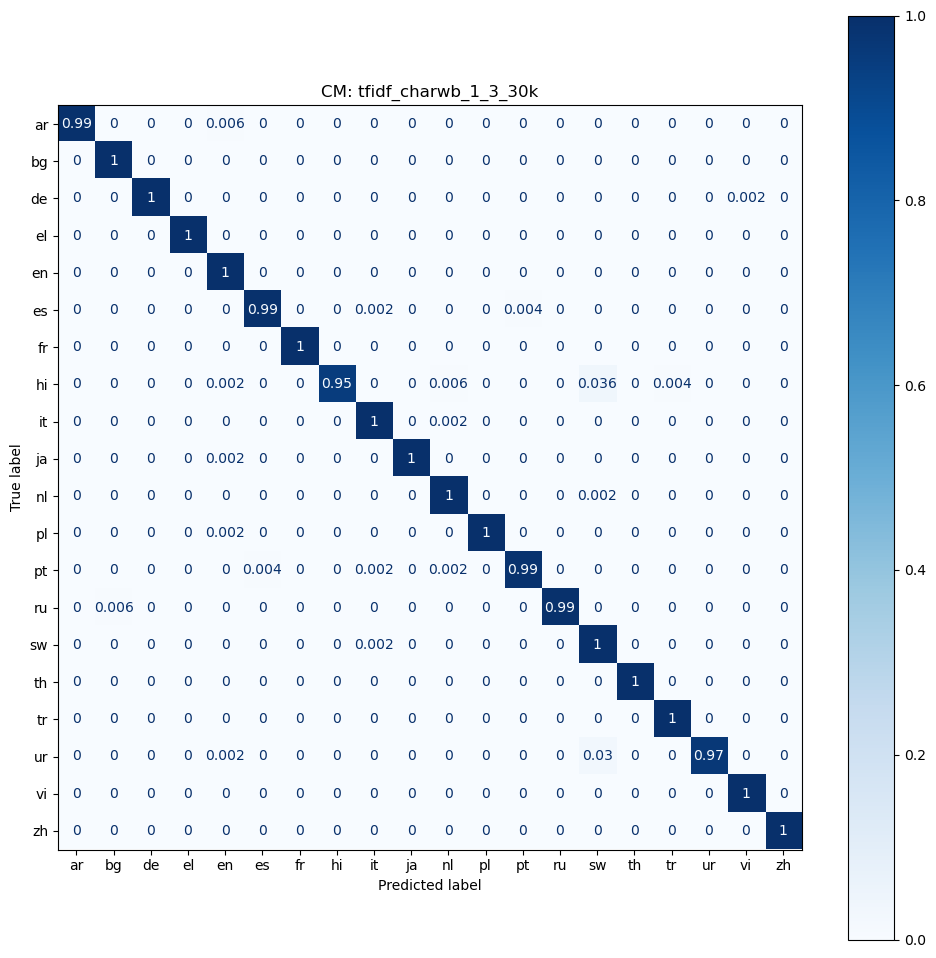

Finished tfidf_charwb_1_3_30k | Run ID: 6c8b516f1b37421d85f67056d8dd1728 | Accuracy: 0.9941


In [21]:
result_tfidf_charwb_1_3_30k = train_and_log_tfidf(
    name="tfidf_charwb_1_3_30k",
    ngram_range=(1, 3),
    analyzer="char_wb",
    max_features=30000,
)
experiment_results.append(result_tfidf_charwb_1_3_30k)

##### TF-IDF 40k with ngram(1, 4) analyzer='char_wb'

2026/05/19 17:46:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:46:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


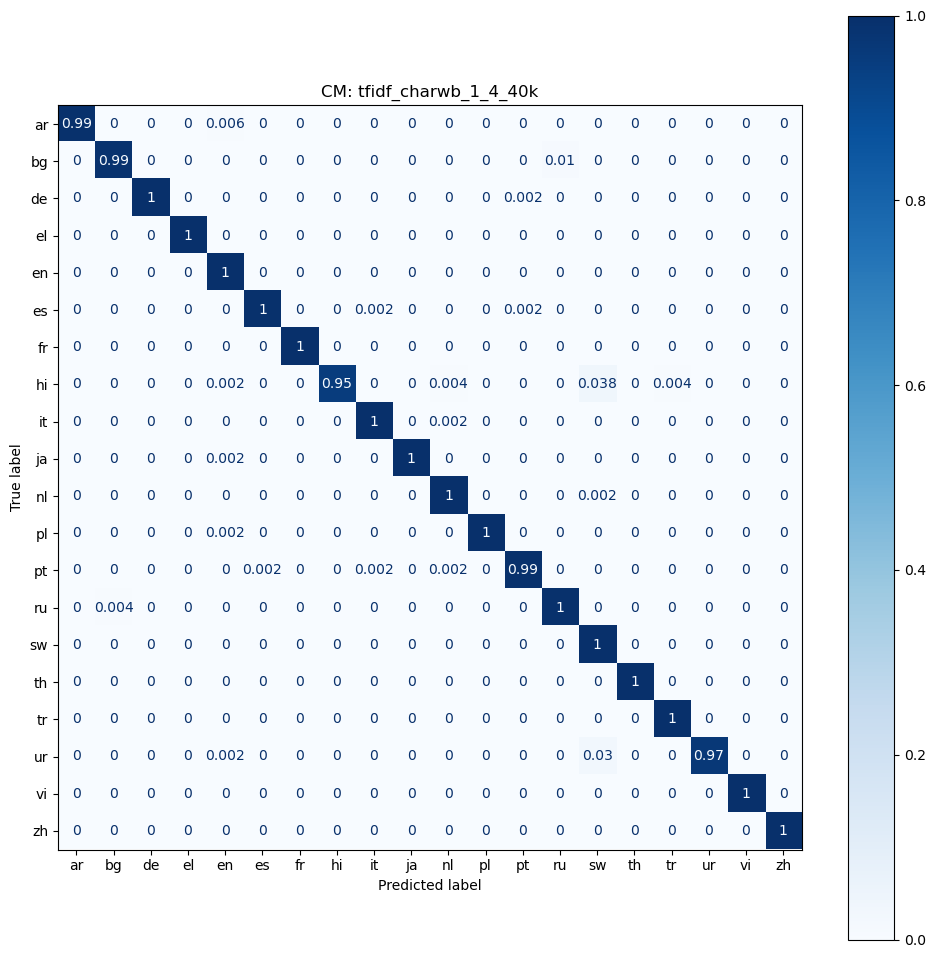

Finished tfidf_charwb_1_4_40k | Run ID: 3fea1f1fa1684166b4272001f04e9944 | Accuracy: 0.9940


In [22]:
result_tfidf_charwb_1_4_40k = train_and_log_tfidf(
    name="tfidf_charwb_1_4_40k",
    ngram_range=(1, 4),
    analyzer="char_wb",
    max_features=40000,
)
experiment_results.append(result_tfidf_charwb_1_4_40k)

##### TF-IDF 40k with ngram(2, 4) analyzer='char_wb'

2026/05/19 17:47:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:47:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


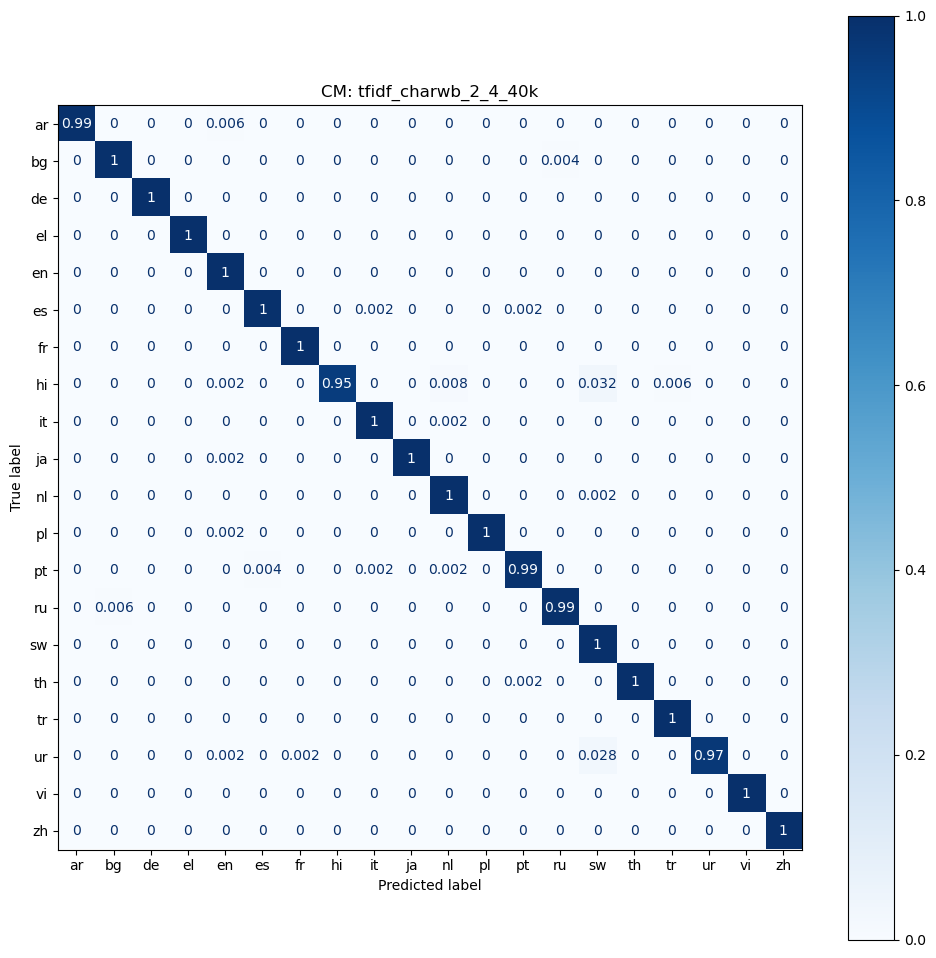

Finished tfidf_charwb_2_4_40k | Run ID: 3f0923b524d44fc4a684ee6199c4eacb | Accuracy: 0.9941


In [23]:
result_tfidf_charwb_2_4_40k = train_and_log_tfidf(
    name="tfidf_charwb_2_4_40k",
    ngram_range=(2, 4),
    analyzer="char_wb",
    max_features=40000,
)
experiment_results.append(result_tfidf_charwb_2_4_40k)

##### TF-IDF 25k with ngram(2, 4) analyzer='char'

2026/05/19 17:47:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:47:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


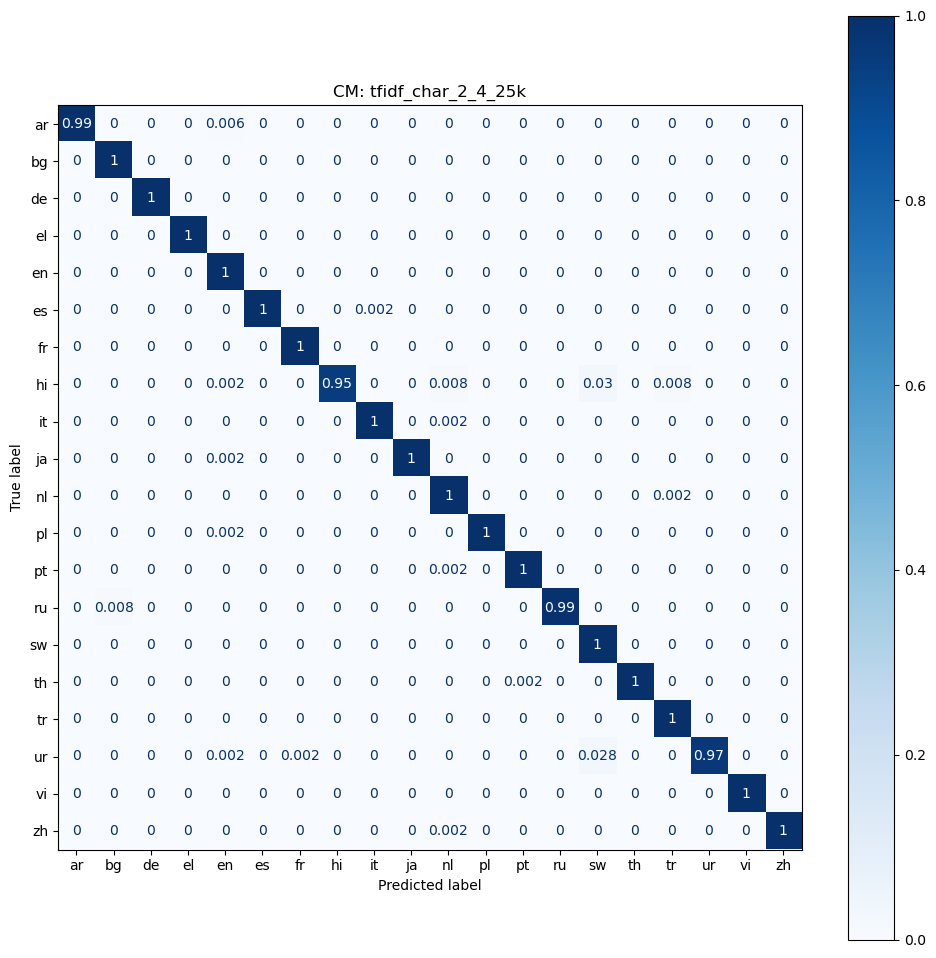

Finished tfidf_char_2_4_25k | Run ID: 1c8a71acffb8437fa6e2cab4ed9fb346 | Accuracy: 0.9945


In [24]:
result_tfidf_char_2_4_25k = train_and_log_tfidf(
    name="tfidf_char_2_4_25k",
    ngram_range=(2, 4),
    analyzer="char",
    max_features=25000,
)
experiment_results.append(result_tfidf_char_2_4_25k)

##### TF-IDF 25k with ngram(1, 5) analyzer='char'

2026/05/19 17:48:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/19 17:48:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


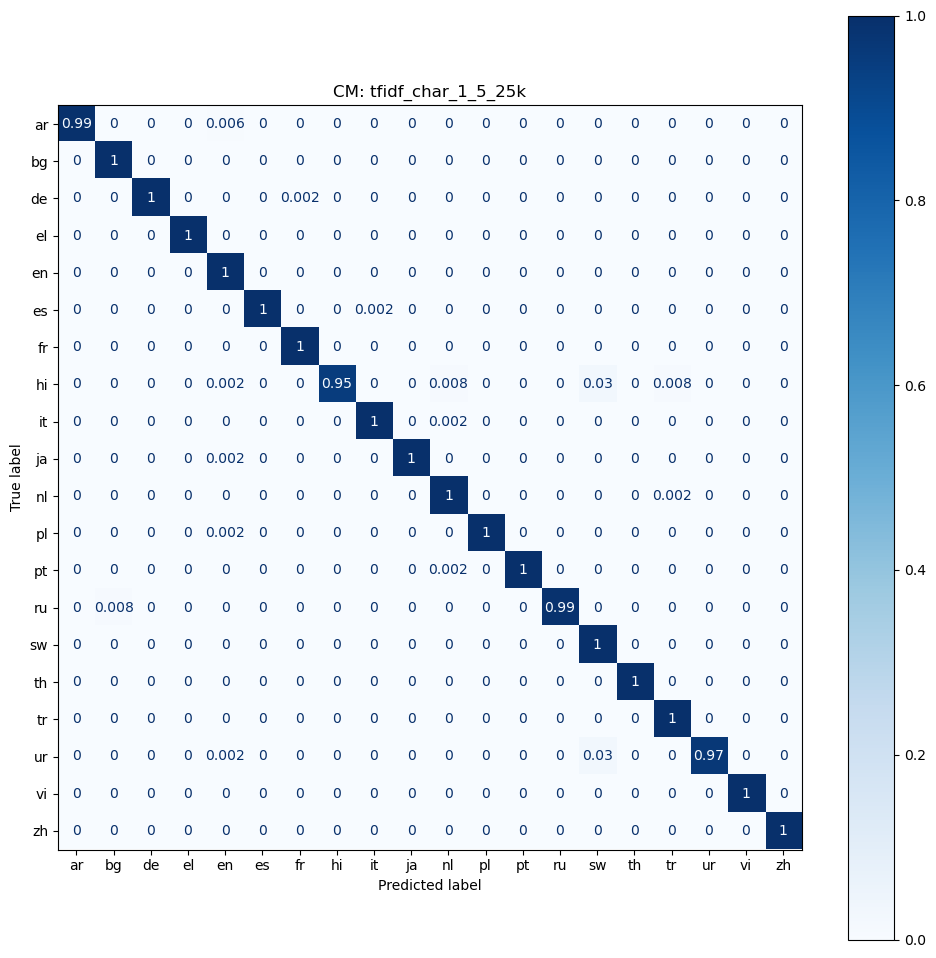

Finished tfidf_char_1_5_25k | Run ID: ca13993f5b2748febb4a628ca5ed0487 | Accuracy: 0.9946


In [25]:
result_tfidf_char_1_5_25k = train_and_log_tfidf(
    name="tfidf_char_1_5_25k",
    ngram_range=(1, 5),
    analyzer="char",
    max_features=25000,
)
experiment_results.append(result_tfidf_char_1_5_25k)

Comparing all experiment results

In [28]:
if not experiment_results:
    raise ValueError("No experiment results found. Run the training cells first.")

# Sort experiments by accuracy descending
results_sorted = sorted(
    experiment_results,
    key=lambda r: r["accuracy"],
    reverse=True
)

# Create clean dataframe for display
results_df = pd.DataFrame([
    {
        "Rank": idx + 1,
        "Experiment": r["name"],
        "Accuracy": round(r["accuracy"], 4)
    }
    for idx, r in enumerate(results_sorted)
])

print("=" * 70)
print("LANGUAGE DETECTION EXPERIMENT RESULTS")
print("=" * 70)

display(results_df)

# Get best experiment
best_result = results_sorted[0]
best_model = best_result["model"]
best_vectorizer = best_result["vectorizer"]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Experiment : {best_result['name']}")
print(f"Accuracy   : {best_result['accuracy']:.4f}")

# Save artifacts
joblib.dump(
    best_model,
    "../artifacts/language_detection_best_model.pkl"
)

joblib.dump(
    best_vectorizer,
    "../artifacts/language_detection_best_vectorizer.pkl"
)

print("\nArtifacts saved successfully in ../artifacts/")

LANGUAGE DETECTION EXPERIMENT RESULTS


,Rank,Experiment,Accuracy
0,1,tfidf_char_1_5_25k,0.9946
1,2,tfidf_char_2_4_25k,0.9945
2,3,tfidf_char_1_3_30k,0.9942
3,4,tfidf_charwb_1_3_30k,0.9941
4,5,tfidf_charwb_2_4_40k,0.9941
5,6,tfidf_charwb_1_4_40k,0.9940
6,7,tfidf_char_1_2_30k,0.9917
7,8,tfidf_word_1_5_35k,0.9316
8,9,tfidf_word_1_2_30k,0.9313
9,10,tfidf_word_1_5_30k,0.9307



BEST MODEL
Experiment : tfidf_char_1_5_25k
Accuracy   : 0.9946

Artifacts saved successfully in ../artifacts/


**Conclusion:** The TF-IDF model with 25,000 features, `ngram_range=(1,5)`, and `analyzer='char'` was selected as the final model because it achieved the highest accuracy and effectively captured character-level patterns in both short and long text samples.

--------

# 6. Test Data

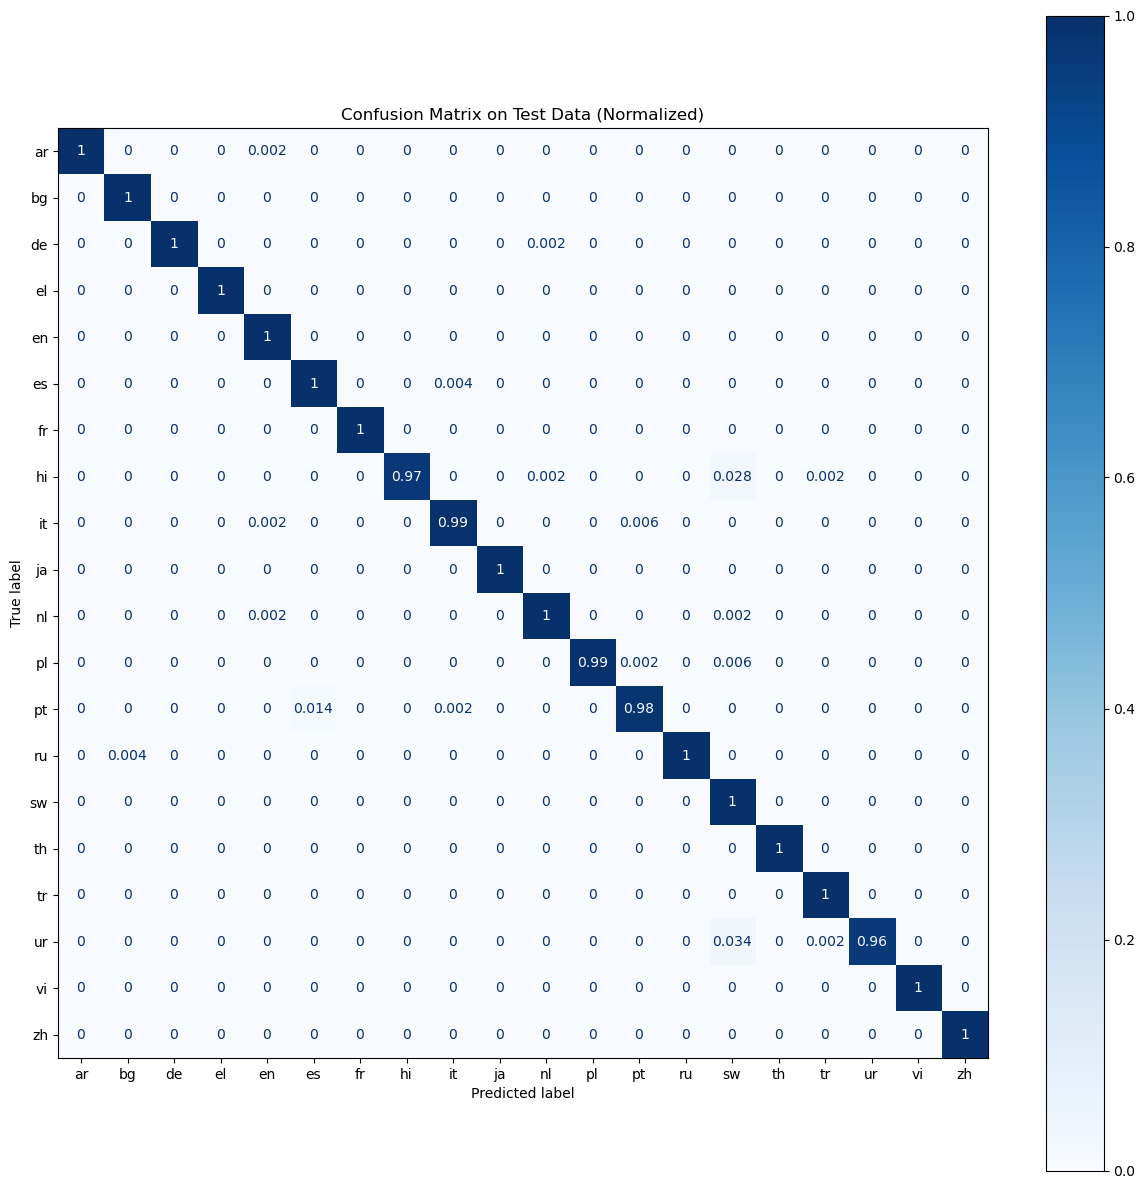

Test Accuracy: 0.9942


In [29]:
# 1. Transform test data and predict
X_test = best_vectorizer.transform(test_ds["text"])
y_test_pred = best_model.predict(X_test)

# 2. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(15, 15))
ConfusionMatrixDisplay.from_predictions(
    test_ds["labels"],
    y_test_pred,
    display_labels=best_model.classes_,
    ax=ax,
    cmap="Blues",
    normalize="true",
)
plt.title("Confusion Matrix on Test Data (Normalized)")
plt.show()

# 3. Print final accuracy
test_acc = accuracy_score(test_ds["labels"], y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

----

# 7. Inference on Test Examples

In [30]:
text = "انا اسمي علاء"
prec_text = preprocess(text)
best_model.predict(best_vectorizer.transform([prec_text]))

array(['ar'], dtype=object)

In [31]:
text = "hello my name is mazen"
prec_text = preprocess(text)
best_model.predict(best_vectorizer.transform([prec_text]))

array(['en'], dtype=object)

In [32]:
text = "je suis malade"
prec_text = preprocess(text)
best_model.predict(best_vectorizer.transform([prec_text]))

array(['fr'], dtype=object)

In [33]:
text = "ภาษาไทย"
prec_text = preprocess(text)
best_model.predict(best_vectorizer.transform([prec_text]))

array(['th'], dtype=object)

In [34]:
text = "こんにちは"
prec_text = preprocess(text)
best_model.predict(best_vectorizer.transform([prec_text]))

array(['ja'], dtype=object)